# Visualization of transform matrices

1) [Shape of an element](#shape-of-an-element-of-the-list)
2) [Show positions](#show-positions)
3) [Show translations](#show-translations)
4) [Show quadtrees](#show-quadtrees)

In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import pickle
from tqdm import tqdm
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# load transforms
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

In [4]:
# print(lst_transforms)
print(len(lst_transforms))
print(len(lst_transforms[4]))

681
3


In [5]:
print(lst_transforms[0][1][0])

lst_levels = set([x[0] for x in lst_transforms])
print(lst_levels)


[2.5010e+06 1.1440e+06 9.7568e+02]
{0, 1, 2, 3, 4, 5}


### Shape of an element of the list:

[level, (min_bound-> list(3), fitness, inlier_rmse, transformation -> array[4,4])]

**transform** = \
[ R | t ] \
[ 0 | 1 ]

**fitness** = "how much overlap you have"
* 1.0 -> all source points matched
* 0.0 -> no overlap, no matching

**inlier_rmse** = "how good the alignment is" (only computed over inliers)
* inliers = points whose distance to a match is < max_correspondence_distance

### Show positions

1
4
16
64
256
340


ValueError: cannot reshape array of size 340 into shape (18,18)

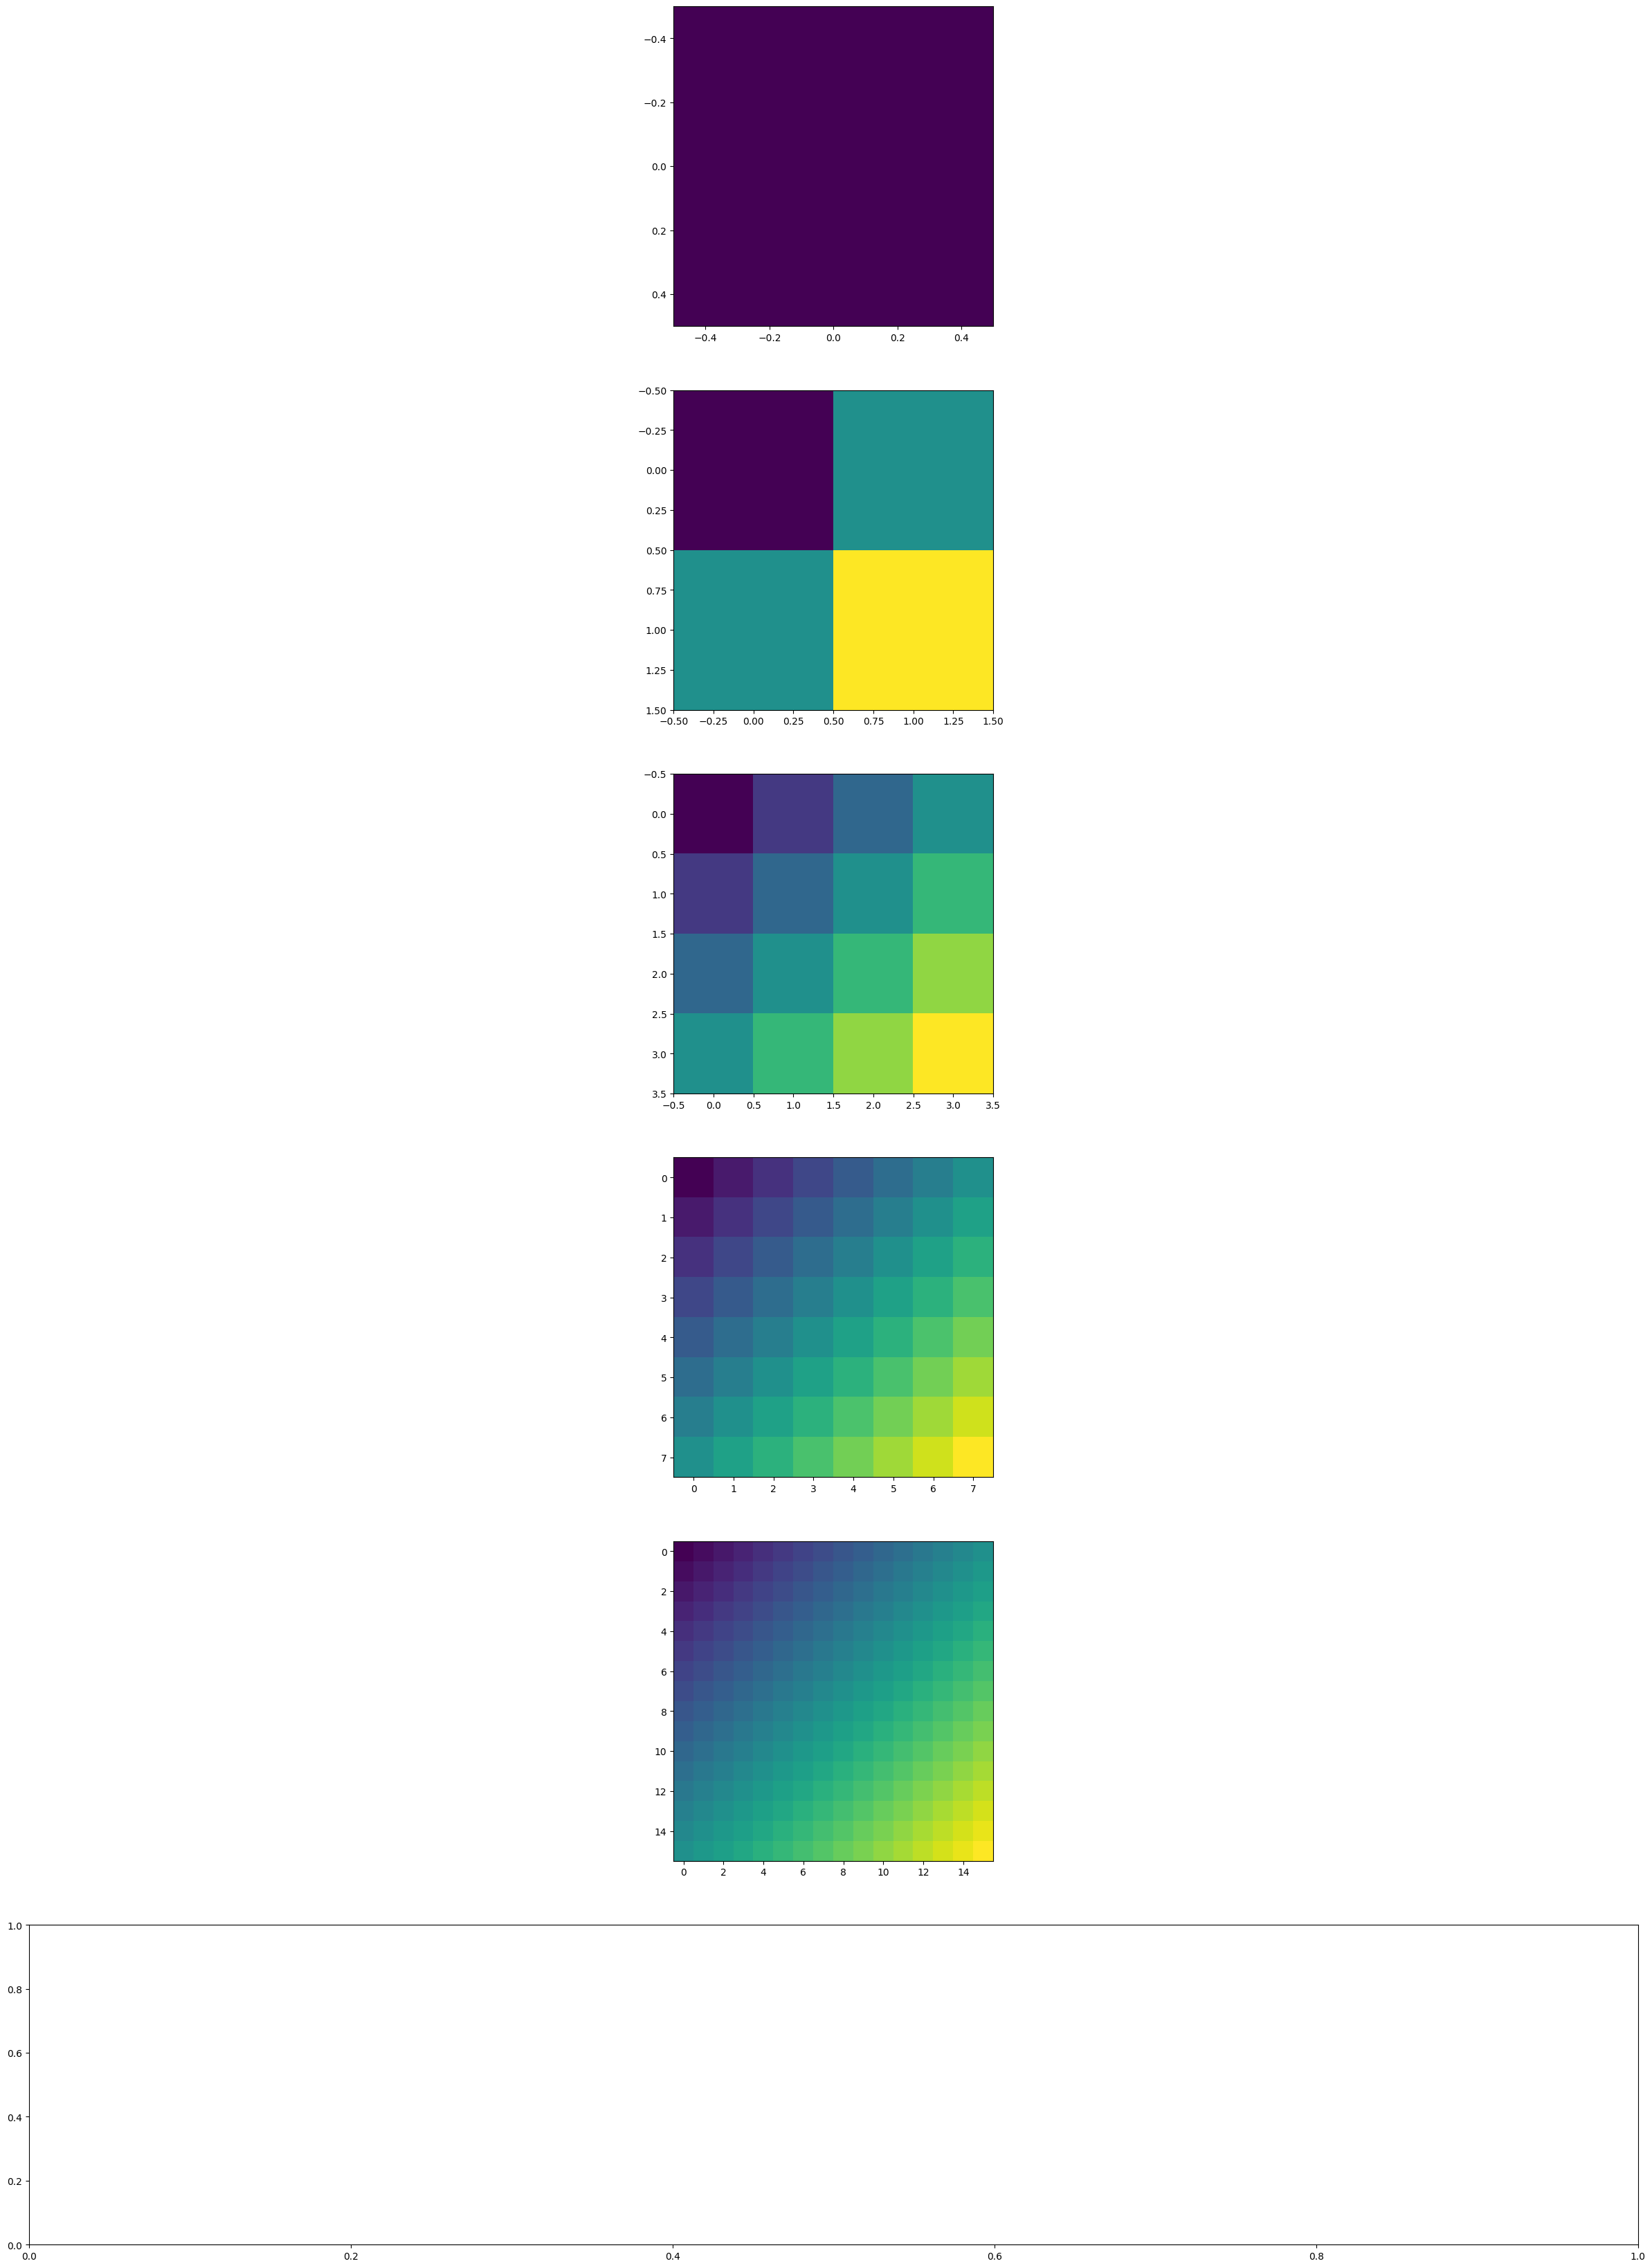

In [6]:
# xbase = 2500000
# ybase = 1144000

fig, axs = plt.subplots(len(lst_levels), 1, figsize=(30, len(lst_levels)*7))
for id_lvl, lvl in enumerate(lst_levels):
    data = [x for x in lst_transforms if x[0] == lvl]
    print(len(data))
    size = int(len(data)**0.5)

    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])

    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    x_poses = x_poses.reshape((size,size))
    for el in data:
        ix = list_x_poses.index(el[1][0][0])
        iy = list_y_poses.index(el[1][0][1])
        transform = el[1][3]
        translation = np.sqrt(np.sum(transform[0:3,3]**2))
        grid[ix,iy] = el[1][0][0] + el[1][0][1]

    y_poses = np.array([x[1][0][1] for x in data]).reshape((size,size))
    axs[id_lvl].imshow(grid)

### Show translations

In [ ]:
xbase = 2500000
ybase = 1144000
# lst_levels = range(3)
fig, axs = plt.subplots(len(lst_levels), 1, figsize=(30, len(lst_levels)*7))
for id_lvl, lvl in enumerate(lst_levels):
    data = [x for x in lst_transforms if x[0] == lvl]
    size = int(len(data)**0.5)
    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])
    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    x_poses = x_poses.reshape((size,size))
    for el in data:
        ix = list_x_poses.index(el[1][0][0])
        iy = list_y_poses.index(el[1][0][1])
        transform = el[1][3]
        translation = np.sqrt(np.sum(transform[0:3,3]**2))
        grid[ix,iy] = translation
    y_poses = np.array([x[1][0][1] for x in data]).reshape((size,size))
    axs[id_lvl].imshow(grid)
    # axs[id_lvl].imshow(y_poses)
    # Loop over data dimensions and create text annotations.
    # for i in range(size):
    #     for j in range(size):
    #         text = axs[id_lvl].text(j, i, f"{data[i+j][1][0][0] - xbase}\n{data[i+j][1][0][1] - ybase}",
    #                     ha="center", va="center", color="w")

### Show quadtrees

In [ ]:
def merge_level(src, lvl, type='source'):
    files = [os.path.join(src, x) for x in os.listdir(src) if f'lvl={lvl}' in x and type in x]

    merged_pc = o3d.geometry.PointCloud()

    for _, f in tqdm(enumerate(files), total=len(files)):
        pc = o3d.io.read_point_cloud(f)
        merged_pc += pc  

    return merged_pc

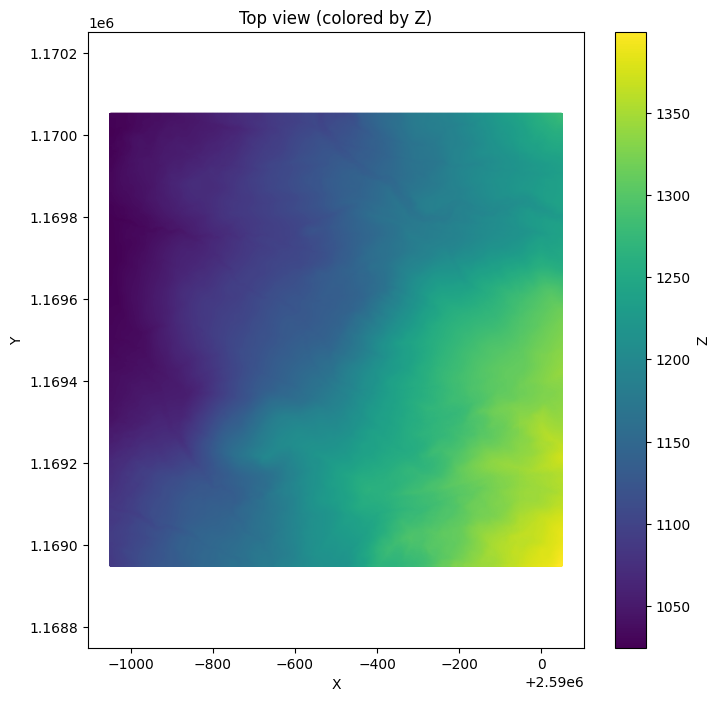

In [20]:
import open3d as o3d

pcd = o3d.io.read_point_cloud(r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\PC2015_2589_1169.ply")
points = np.asarray(pcd.points)

x = points[:, 0]
y = points[:, 1]
z = points[:, 2]

plt.figure(figsize=(8, 8))

# Color by height (optional but very useful)
plt.scatter(x, y, c=z, s=1, cmap='viridis')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Top view (colored by Z)")
plt.axis('equal')
plt.colorbar(label="Z")

plt.show()

In [ ]:
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
src_tiles = os.path.join(os.path.dirname(src_transforms), 'pointclouds')
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

# xbase = 2500000
# ybase = 1144000
data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 1, figsize=(7, max_lvl*7))


while len(storage) < len(lst_transforms):
    print("level: ", lvl)
    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    merged_pc = merge_level(src_tiles, lvl)
    points = np.asarray(merged_pc.points)

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    # plt.figure(figsize=(8, 8))

    # Color by height (optional but very useful)
    axs[lvl].scatter(x, y, c=z, s=1, cmap='viridis')

    # plt.xlabel("X")
    # plt.ylabel("Y")
    # plt.title("Top view (colored by Z)")
    # plt.axis('equal')
    # axs[lvl].set_colorbar(label="Z")

    # plt.show()

    # axs[lvl].set_title(f'level {lvl}')
    # im = axs[lvl].imshow(grid)
    # cbar = axs[lvl].figure.colorbar(im, ax=axs[lvl])
    lvl += 1

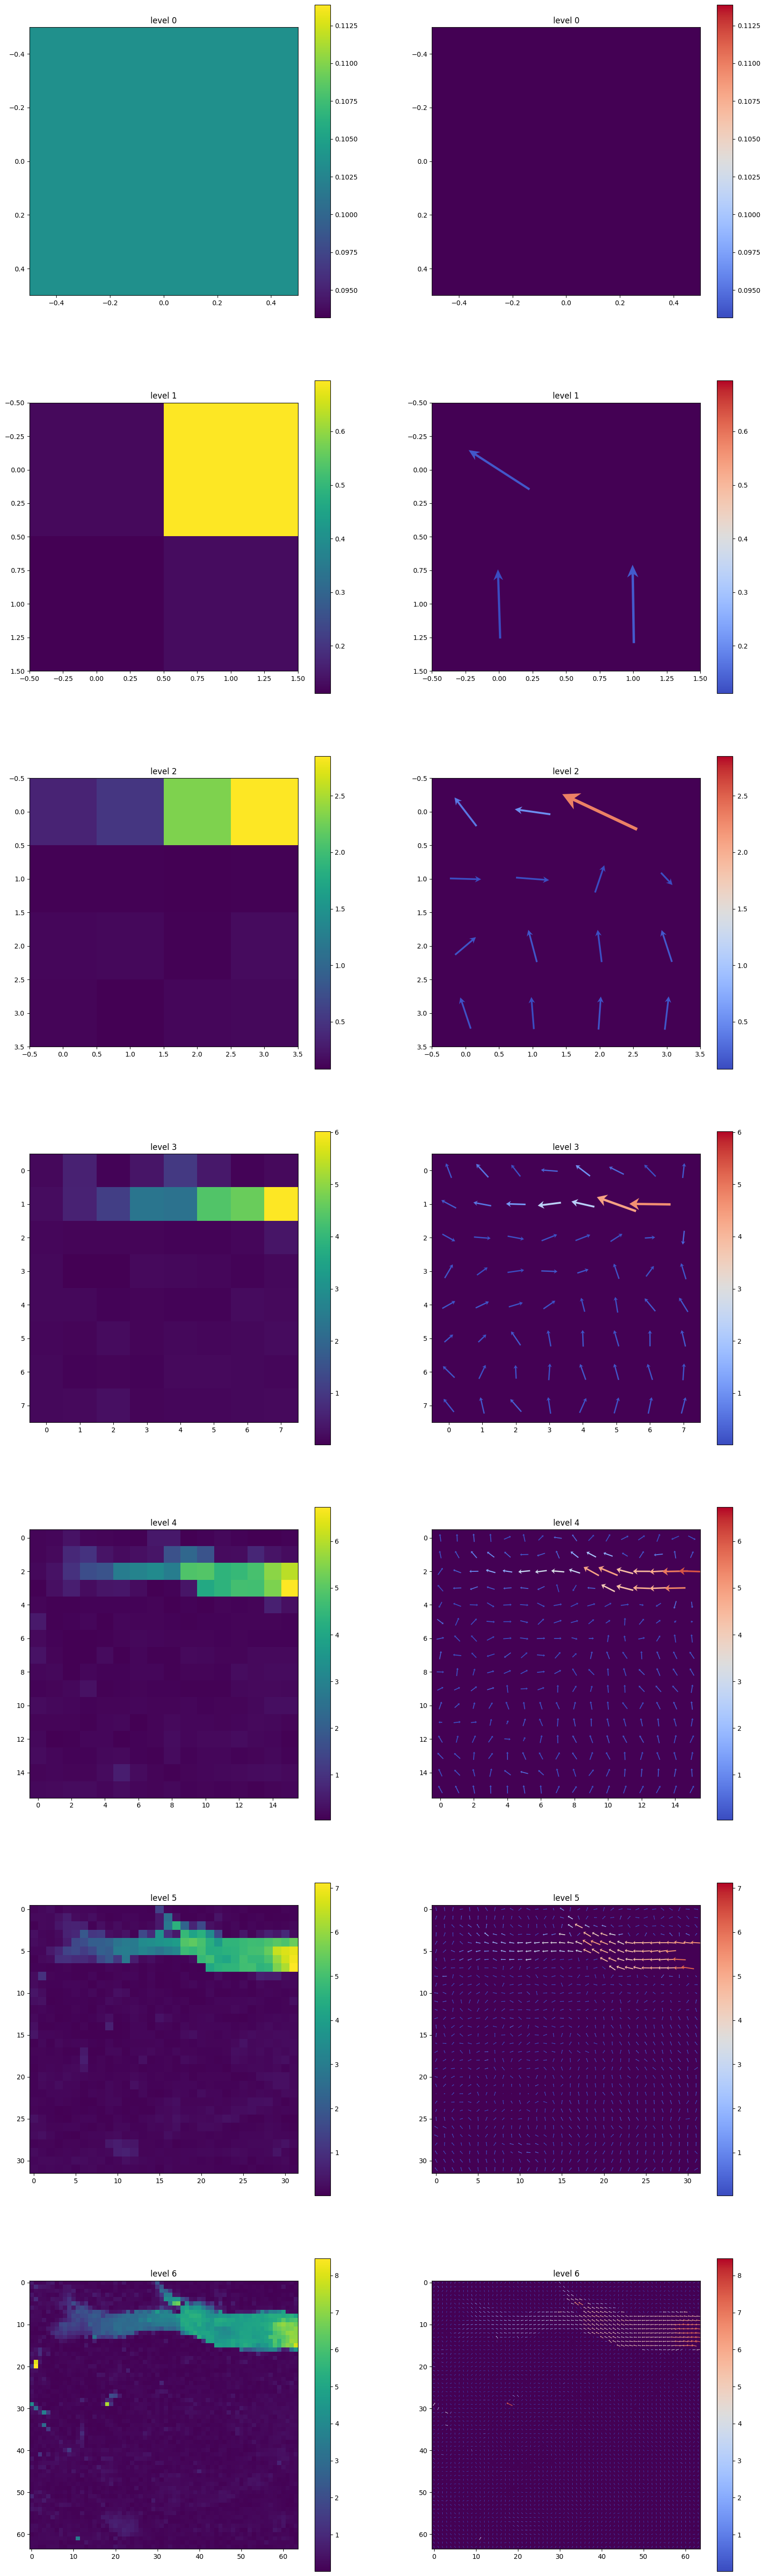

In [68]:
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\test_full\results\pyramid_transforms_test.pickle"
src_tile_original = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\test_full\PC2015_2589_1169.ply"
do_save = True

src_res_img = os.path.join(os.path.dirname(src_transforms), 'images')
os.makedirs(src_res_img, exist_ok=True)

tile_original = o3d.io.read_point_cloud(src_tile_original)
z_mean = tile_original.compute_mean_and_covariance()[0][2]
tile_original.translate(np.array([-2589500, -1169500, 0]) - np.array([0, 0, z_mean]))

with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 2, figsize=(20, max_lvl*10))
while len(storage) < len(lst_transforms):
    X, Y, U, V, norms = [], [], [], [] , []

    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    # x_poses = np.array([x[1][0][0] for x in data])
    # y_poses = np.array([x[1][0][1] for x in data])
    x_poses = np.array([x[1][0]['min_bound'][0] for x in data])
    y_poses = np.array([x[1][0]['min_bound'][1] for x in data])
    # list_x_poses, list_y_poses = [], []
    # for x in data:
    #     bbox_dict = el[1][0]
    #     min_bound = o3d.geometry.AxisAlignedBoundingBox(
    #         min_bound=np.array(bbox_dict["min_bound"]),
    #         max_bound=np.array(bbox_dict["max_bound"])
    #     ).get_min_bound()
    #     list_x_poses.append(bbox)
    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        bbox_dict = el[1][0]
        bbox = o3d.geometry.AxisAlignedBoundingBox(
            min_bound=np.array(bbox_dict["min_bound"]),
            max_bound=np.array(bbox_dict["max_bound"])
        )
        # min_bound = bbox.get_min_bound()
        
        ix = size - list_y_poses.index(bbox_dict["min_bound"][1]) - 1
        iy = list_x_poses.index(bbox_dict["min_bound"][0])

        # === HEATMAP ===
        # translation:
        transform = el[1][3]
        # val = np.sqrt(np.sum(transform[0:3,3]**2))
        # val = np.sum(transform[0:3,3])
        cropped_tile = tile_original.crop(bbox)
        # print(bbox_dict)
        # print(np.array(tile_original.points).shape)
        center = np.vstack([np.mean(np.array(cropped_tile.points), axis=0).reshape((3,1)), np.array([1])])
        # center_4 = np.array([center[0], center[1], center[2], 1]).reshape((4,1))
        translated = np.linalg.matmul(transform, center)
        norm = float(np.linalg.norm(translated - center))



        delta = 2**(lvl - el[0])
        grid[ix:ix+delta,iy:iy+delta] = norm

        # === QUIVER ===
        # translation:
        # norm = np.linalg.norm(transform[0:2,3])
        norms.append(norm)
        # direction = transform[0:2,3] / norm * tile_size / 2
        direction = (translated - center) / norm
        # tile_size = 2**(lvl - el[0])

        # store vector at tile center
        cx = iy
        cy = ix

        X.append(cx)
        Y.append(cy)
        U.append(direction[0])
        V.append(-direction[1])  # minus because imshow flips Y axis
        
    axs[lvl, 0].set_title(f'level {lvl}')
    axs[lvl, 1].set_title(f'level {lvl}')
    lvl_factor = np.clip(lvl/max_lvl * 3, 0.5, 3)

    # === SHOW HEATMAP ===
    im = axs[lvl, 0].imshow(grid)
    cbar = axs[lvl, 0].figure.colorbar(im, ax=axs[lvl, 0])

    # === SHOW QUIVER ===
    axs[lvl, 1].imshow(np.zeros(grid.shape))
    # bins = [0, 0.1, 0.2, 0.5, 1.0, 2.0,]  # adjust to your data
    bins = np.arange(0, np.max(norms), np.max(norms)/11)
    importance_factor = np.arange(1, 2, 1/10)
    # scales = np.arange(2, 0.001, -1.999/10)
    scales = np.arange(2, 0.5, -1.5/10)
    arrow_heads_w_l = [(x,y) for x,y in zip(np.arange(3,0.1,-2.9/10), np.arange(5,0.1,-4.9/10))]

    X, Y, U, V, norms = np.array(X), np.array(Y), np.array(U), np.array(V), np.array(norms)

    for i in range(importance_factor.shape[0]):
        mask = (norms >= bins[i]) & (norms < bins[i+1])
        w = 0.03/size * lvl_factor * importance_factor[i]
        qu = axs[lvl, 1].quiver(
            X[mask], Y[mask], U[mask], V[mask], norms[mask],
            color='white',
            # scale=scales[i],          # adjust this!
            scale=scales[i],          # adjust this!
            scale_units='xy',
            angles='xy',
            pivot='middle',
            width=w,
            headwidth=3 / 1.1**lvl * (importance_factor[i]+0.5),
            headlength=4 / 1.3**lvl * (importance_factor[i]+0.5),
            headaxislength= 3 / 1.3**lvl * (importance_factor[i]+0.5),
            cmap="coolwarm",
            norm=mcolors.Normalize(vmin=np.min(norms), vmax=np.max(norms))
        )
    
    cbar = axs[lvl, 1].figure.colorbar(qu, ax=axs[lvl, 1])
    lvl += 1
    if do_save:
        plt.savefig(os.path.join(src_res_img, 'results.png'), dpi=300)

In [51]:
A = np.array([1,2,3]).reshape((3,1))
B = np.array([1])
print(A.shape)
print(B.shape)
C = np.vstack([A,B])
print(C.shape)

(3, 1)
(1,)
(4, 1)


### Show AoI movement through levels

In [ ]:
level=5
ix=16
iy=16

fig, axs = plt.subplots(level, 1, figsize=(10, 10*level))
for lvl in level:
    

In [17]:
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150
plt.ioff()
fig, ax = plt.subplots()

x= np.linspace(0,10,1000)
# def animate(t):
#     print(t)
#     plt.cla()
#     plt.plot(x-t*0.1,x)
#     plt.xlim(0,10)
def animate(i):
    plt.cla()
    plt.scatter(i, 0)
    plt.xlim(0,50)
    # scat.set_offsets((x[i], 0))
    # return (scat,)
matplotlib.animation.FuncAnimation(fig, animate, frames=50, interval=42)

### Temp

#### Apply small translation to pointcloud

In [11]:
import open3d as o3d
import laspy
import os
from copy import deepcopy
from format_conversions import convert_all_in_folder

def read_pc(src_pc):
    ext = os.path.splitext(src_pc)[1].lower()

    if ext in ['.ply', '.pcd', '.xyz', '.xyzrgb', '.xyzn', '.pts']:
        return o3d.io.read_point_cloud(src_pc)
    elif ext in ['.las', '.laz']:
        xyz = laspy.read(src_pc)
        pc = o3d.geometry.PointCloud()
        pc.points = o3d.utility.Vector3dVector(xyz.xyz)
        return pc
    else:
        raise AttributeError(f"Wrong extension '{ext}'. Should be in '.ply', '.pcd', '.xyz', '.xyzrgb', '.xyzn', '.pts', '.las' and '.laz")
    
def compute_bbox(boundaries):
    min_bound, max_bound = boundaries.get_min_bound(), boundaries.get_max_bound()
    minx, miny, minz = min_bound
    maxx, maxy, maxz = max_bound
    spanx = (maxx-minx) / 2
    spany = (maxy-miny) / 2
    bboxes = []
    for i in range(2):
        for j in range(2):
            x0 = int(minx + i * spanx)
            y0 = int(miny + j * spany)
            x1 = int(x0 + spanx)
            y1 = int(y0 + spany)
            bboxes.append(o3d.geometry.AxisAlignedBoundingBox((x0, y0, minz), (x1, y1, maxz)))
    return bboxes



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [21]:
# Apply small translation to pointcloud
src = "data/test_artificial_movement/2024_2501_1144.las"
pc = read_pc(src)

print(len(pc.points))

44568618


In [22]:
# pc_translate = deepcopy(pc).translate((2,2,0))

In [ ]:

bbox = pc.get_axis_aligned_bounding_box()
bboxes = compute_bbox(bbox)
bboxes = compute_bbox(bboxes[3])
# print(bboxes)

In [ ]:
points = np.asarray(pc.points)
# for bbox, shift in zip([bboxes[1], bboxes[2]], [(0.1, 0.1, 0), (0.2, 0.2, 0)]):
for bbox, shift in zip([bboxes[0]], [(0.1, 0.1, 0)]):

    # Get indices of points inside bbox
    indices = bbox.get_point_indices_within_bounding_box(pc.points)
    # points[indices] += np.array([1, 1, 0]) * (points[indices][:,0] > threshold)

    # Apply translation directly
    points[indices] += np.array(shift)

In [25]:
src_res = "data/test_artificial_movement/2024_2501_1144_movement_in_some_part.ply"
o3d.io.write_point_cloud(src_res, pc)

True

In [ ]:
src_folder = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement"
convert_all_in_folder(src_folder, src_folder, 'las', 'ply')

In [ ]:
src_pc = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\2024_2501_1144_movement.ply"
pc = o3d.io.read_point_cloud(src_pc)
bbox = pc.get_axis_aligned_bounding_box()
print(bbox.get_min_bound())
print(bbox.get_max_bound())

In [ ]:
print(bbox.get_min_bound())
print(bbox.get_max_bound())

#### Transform csv into ply and laz

In [44]:
import pandas as pd
from simpledbf import Dbf5
src_file = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\PointClouds\PC2015_2589_1169.csv"
src_file = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\PointClouds\PC2019_2589_1169.dbf"
dbf = Dbf5(src_file)
csv = dbf.to_dataframe()
# csv = pd.read_csv(src_file, sep=',')
print(csv.head())
print(csv.columns)


            X           Y         Z   nX   nY   nZ
0  2588950.25  1170049.75  1027.776  0.0  0.0  1.0
1  2588950.75  1170049.75  1027.788  0.0  0.0  1.0
2  2588951.25  1170049.75  1027.802  0.0  0.0  1.0
3  2588951.75  1170049.75  1027.814  0.0  0.0  1.0
4  2588952.25  1170049.75  1027.850  0.0  0.0  1.0
Index(['X', 'Y', 'Z', 'nX', 'nY', 'nZ'], dtype='object')


In [45]:
xyz = csv[['X','Y','Z']]
print(xyz.head())

            X           Y         Z
0  2588950.25  1170049.75  1027.776
1  2588950.75  1170049.75  1027.788
2  2588951.25  1170049.75  1027.802
3  2588951.75  1170049.75  1027.814
4  2588952.25  1170049.75  1027.850


In [47]:
xyz_arr = xyz.to_numpy()
print(xyz_arr.shape)

(4840000, 3)


In [49]:
import open3d as o3d
import numpy as np

src_output_file = src_file.replace('.dbf', '.ply')

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()

# Assign points
pcd.points = o3d.utility.Vector3dVector(xyz_arr)

# Save to PLY
o3d.io.write_point_cloud(src_output_file, pcd)

True

#### merge each level together

In [166]:
# level = 5
for level in range(1,4):
    type='source'
    src_pc = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pointclouds"
    src_merged = os.path.join(os.path.dirname(src_pc), f'merged_level_{level}_{type}.pcd')
    files = [os.path.join(src_pc, x) for x in os.listdir(src_pc) if f'lvl={level}' in x and type in x]
    print(len(files))

    merged_pcd = o3d.geometry.PointCloud()

    for _, f in tqdm(enumerate(files), total=len(files)):
        pcd = o3d.io.read_point_cloud(f)
        merged_pcd += pcd  # merge

    o3d.io.write_point_cloud(src_merged, merged_pcd)

4


100%|██████████| 4/4 [00:00<00:00, 675.52it/s]


16


100%|██████████| 16/16 [00:00<00:00, 2243.39it/s]


64


100%|██████████| 64/64 [00:00<00:00, 138.24it/s]


In [151]:
pcd = o3d.io.read_point_cloud(r"data\test_real_movement\test_small_sample\level_3\alligned_pc_lvl=3_x=274.0_y=274.0_target.pcd")
o3d.io.write_point_cloud(r"data\test_real_movement\test_small_sample\level_3\alligned_pc_lvl=3_x=274.0_y=274.0_target.ply", pcd)

True

#### TEMP

In [158]:
with open(r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\test\results\pyramid_transforms_target.pickle", 'rb') as f:
    data = pickle.load(f)
print(data[0][1][3])
transform = data[0][1][3]
print(np.linalg.norm(transform[0:3,3]))

[[ 9.99546123e-01 -2.90742184e-02  7.88910782e-03  1.32348917e+01]
 [ 2.90322813e-02  9.99564000e-01  5.37929518e-03 -1.30212986e+00]
 [-8.04206697e-03 -5.14781485e-03  9.99954412e-01  2.51831050e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
13.535131678092107


### Trash

[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]


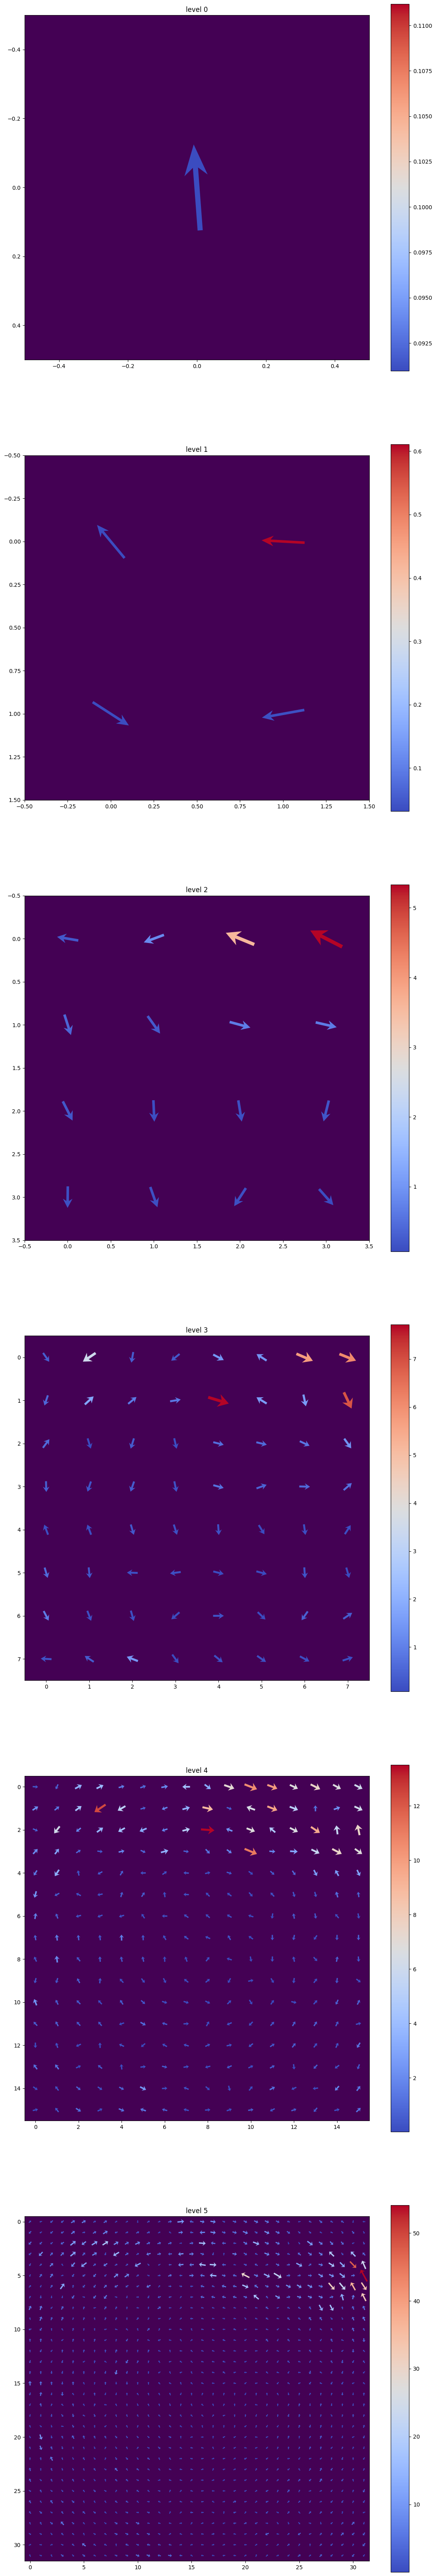

In [ ]:
import matplotlib.colors as mcolors
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 1, figsize=(14, max_lvl*14))
# fig, axs = plt.subplots(1, 2, figsize=(14, 7))
while len(storage) < len(lst_transforms):
    X, Y, U, V, norms = [], [], [], [] , []
    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    tile_size = 1
    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])

    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        ix = size - list_y_poses.index(el[1][0][1]) - 1
        iy = list_x_poses.index(el[1][0][0])

        # translation:
        transform = el[1][3]
        norm = np.linalg.norm(transform[0:2,3])
        norms.append(float(norm))
        direction = transform[0:2,3] / norm * tile_size / 2
        val = np.linalg.norm(transform[0:3, 3])
        val=0
        tile_size = 2**(lvl - el[0])
        grid[ix:ix+tile_size,iy:iy+tile_size] = val


        # store vector at tile center
        cx = iy
        cy = ix

        X.append(cx)
        Y.append(cy)
        U.append(direction[0])
        V.append(-direction[1])  # minus because imshow flips Y axis
    lvl_factor = np.clip(lvl/max_lvl * 3, 0.5, 3)
    # lvl=0
    axs[lvl].set_title(f'level {lvl}')
    im = axs[lvl].imshow(grid)

    # show arrows
    bins = [0, 1, 2, 3, 5, 7, 10, 20, 50, 100, np.inf]  # adjust to your data
    # importance_factor = [1,2,3]
    importance_factor = np.arange(1, 2, 1/10)
    scales = np.arange(2, 0.001, -1.999/10)
    print(scales)
    arrow_heads_w_l = [(x,y) for x,y in zip(np.arange(3,0.1,-2.9/10), np.arange(5,0.1,-4.9/10))]
    # print(importance_factor.shape)
    X = np.array(X)
    Y = np.array(Y)
    U = np.array(U)
    V = np.array(V)
    norms = np.array(norms)

    for i in range(len(importance_factor)):
        mask = (norms >= bins[i]) & (norms < bins[i+1])
        w = 0.03/size * lvl_factor * importance_factor[i]
        qu = axs[lvl].quiver(
            X[mask], Y[mask], U[mask], V[mask], norms[mask],
            color='white',
            scale=scales[i],          # adjust this!
            scale_units='xy',
            angles='xy',
            pivot='middle',
            width=w,
            headwidth=3 / 1.1**lvl * (importance_factor[i]+0.5),
            headlength=4 / 1.3**lvl * (importance_factor[i]+0.5),
            headaxislength= 3 / 1.3**lvl * (importance_factor[i]+0.5),
            cmap="coolwarm",
            norm=mcolors.Normalize(vmin=np.min(norms), vmax=np.max(norms))
        )
    
    cbar = axs[lvl].figure.colorbar(qu, ax=axs[lvl])
    # cbar = axs[lvl].figure.colorbar(im, ax=axs[lvl])
    lvl += 1
    # break

level:  0
0 - 0
2588950.25 - 1168950.25
val: 94.75414481377544
fitness: 0.9632202479338843
rmse: 0.15103053045028772
[[ 9.99999999e-01 -3.15468833e-05  1.24937148e-05  3.68879341e+01]
 [ 3.15468980e-05  1.00000000e+00 -1.17761979e-06 -8.15892868e+01]
 [-1.24936776e-05  1.17801393e-06  1.00000000e+00  3.09970410e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
---


TypeError: 'Axes' object is not subscriptable

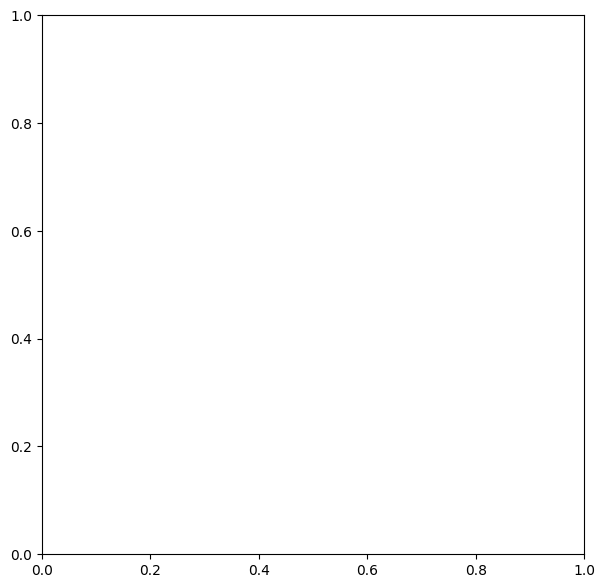

In [ ]:
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

# xbase = 2500000
# ybase = 1144000
data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 1, figsize=(7, max_lvl*7))
while len(storage) < len(lst_transforms):
    print("level: ", lvl)
    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])

    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        ix = size - list_y_poses.index(el[1][0][1]) - 1
        iy = list_x_poses.index(el[1][0][0])
        # position:
        # val = el[1][0][0] + el[1][0][1]

        # translation:
        transform = el[1][3]
        val = np.sqrt(np.sum(transform[0:3,3]**2))
        # val = np.sum(transform[0:3,3])

        size = 2**(lvl - el[0])
        grid[ix:ix+size,iy:iy+size] = val
        print(ix, '-', iy)
        print(el[1][0][0], '-', el[1][0][1])
        print("val:", val)
        print("fitness:" , el[1][1])
        print("rmse:" , el[1][2])
        print(transform)
        # print(transform[0:3,3])
    print('---')
    axs[lvl].set_title(f'level {lvl}')
    im = axs[lvl].imshow(grid)
    cbar = axs[lvl].figure.colorbar(im, ax=axs[lvl])
    lvl += 1
    # remove element of data that is not last
    # for el in [x for x in data if x[-1] == False]:
    #     print(el)
    #     data.remove(el)
        # print(len(data))